### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


In [2]:
# Criando uma coluna identificadora para cada loja
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

# Concatenando todas em um único DataFrame para facilitar a comparação
df_total = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

### Metodologia de Organização dos Dados

Para realizar uma análise comparativa eficiente entre as quatro unidades da **Alura Store**, adotei a estratégia de **Identificação e Concatenagem**:

1.  **Criação de Identificadores:** Como cada arquivo CSV representava uma loja diferente, criei uma nova coluna chamada `Loja` em cada DataFrame individual (`loja_1`, `loja_2`, etc.). Isso garante que a origem do dado não seja perdida após a união.
2.  **Unificação (Concatenação):** Utilizei a função `pd.concat()` para unir as quatro tabelas em um único DataFrame mestre (`df_total`).
3.  **Vantagem:** Essa estrutura permite utilizar funções de agrupamento como o `.groupby()`. Com um único comando, o Python separa os dados internamente por loja, calcula as métricas (soma de faturamento, média de avaliação, etc.) e gera gráficos comparativos de forma automática e escalável.


In [3]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 9435 non-null   object 
 1   Categoria do Produto    9435 non-null   object 
 2   Preço                   9435 non-null   float64
 3   Frete                   9435 non-null   float64
 4   Data da Compra          9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Local da compra         9435 non-null   object 
 7   Avaliação da compra     9435 non-null   int64  
 8   Tipo de pagamento       9435 non-null   object 
 9   Quantidade de parcelas  9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Loja                    9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB


In [4]:
# Importação de bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

#1. Análise do faturamento



Faturamento Total por Loja:
Loja
Loja 1    1534509.12
Loja 2    1488459.06
Loja 3    1464025.03
Loja 4    1384497.58
Name: Preço, dtype: float64


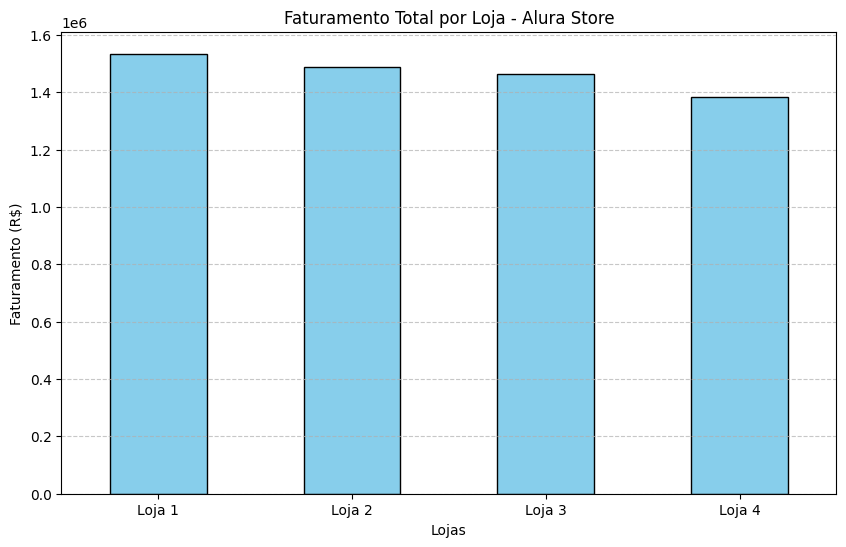

In [5]:
# Calculando o faturamento total por loja
faturamento_por_loja = df_total.groupby('Loja')['Preço'].sum().sort_values(ascending=False)

# Exibindo os valores numéricos
print("Faturamento Total por Loja:")
print(faturamento_por_loja)

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
faturamento_por_loja.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Faturamento Total por Loja - Alura Store')
plt.xlabel('Lojas')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Vendas por Categoria

Quantidade de vendas por categoria em cada loja:


Categoria do Produto,brinquedos,eletrodomesticos,eletronicos,esporte e lazer,instrumentos musicais,livros,moveis,utilidades domesticas
Loja,,,,,,,,
Loja 1,324,312,448,284,182,173,465,171
Loja 2,313,305,422,275,224,197,442,181
Loja 3,315,278,451,277,177,185,499,177
Loja 4,338,254,451,277,170,187,480,201


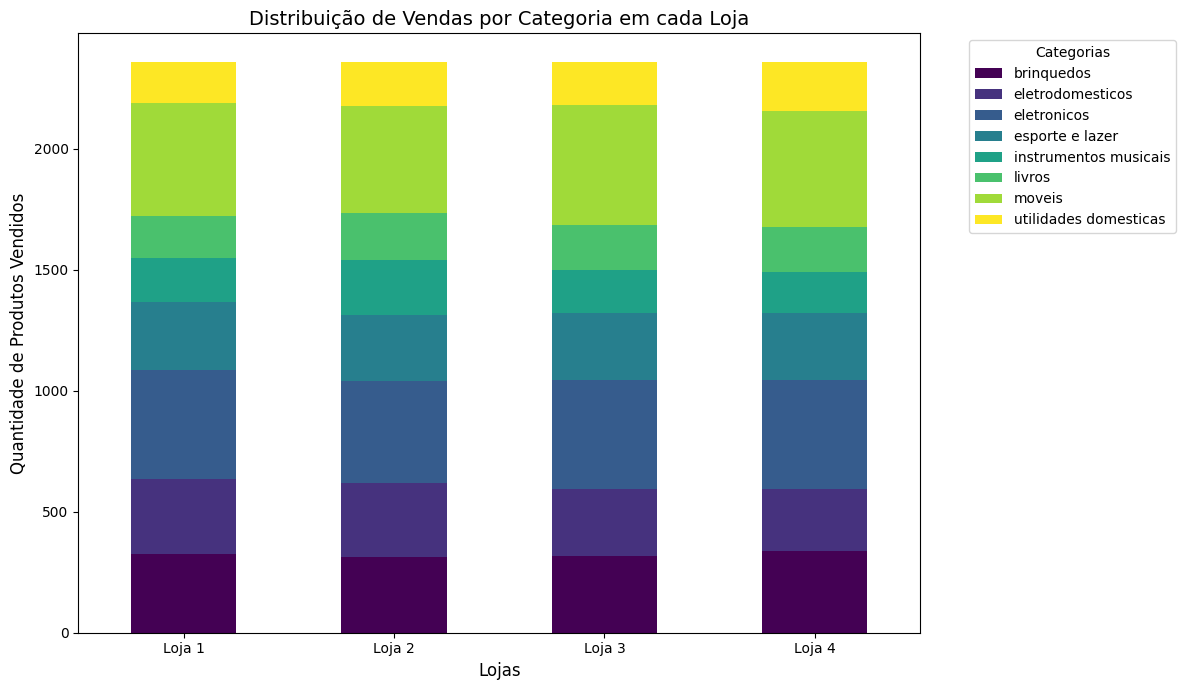

In [6]:
# Contando as vendas por Loja e por Categoria
vendas_categoria = df_total.groupby(['Loja', 'Categoria do Produto']).size().unstack(fill_value=0)

# Exibindo a tabela para conferência
print("Quantidade de vendas por categoria em cada loja:")
display(vendas_categoria)

# Criando o gráfico (Gráfico de Barras Empilhadas
vendas_categoria.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Distribuição de Vendas por Categoria em cada Loja', fontsize=14)
plt.xlabel('Lojas', fontsize=12)
plt.ylabel('Quantidade de Produtos Vendidos', fontsize=12)
plt.legend(title='Categorias', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. Média de Avaliação das Lojas


Média de Avaliação das Lojas 0 - 5
Loja
Loja 1    3.976685
Loja 2    4.037304
Loja 3    4.048326
Loja 4    3.995759
Name: Avaliação da compra, dtype: float64


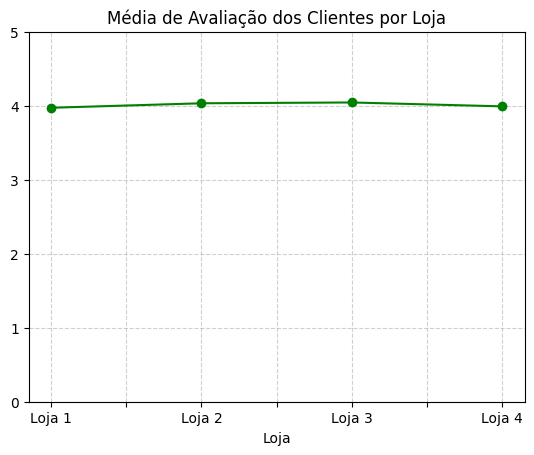

In [7]:
# Calculando a média de avaliação por loja
avaliacao_media = df_total.groupby('Loja')['Avaliação da compra'].mean()

# Exibindo os valores
print('Média de Avaliação das Lojas 0 - 5')
print(avaliacao_media)

# Criando o gráfico (Gráfico de Linhas com Marcadores)
avaliacao_media.plot(kind='line', marker='o', color='green')
plt.title('Média de Avaliação dos Clientes por Loja')
plt.ylim(0, 5) # Escala de 0 a 5 estrelas
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Produtos Mais e Menos Vendidos

Top 5 Produtos Mais Vendidos:
Produto
Cômoda                      210
Carrinho controle remoto    206
Micro-ondas                 206
Bateria                     203
Cama king                   201
Name: count, dtype: int64

5 Produtos Menos Vendidos:
Produto
Ciência de dados com python    166
Guitarra                       165
Mochila                        163
Headset                        158
Celular ABXY                   157
Name: count, dtype: int64


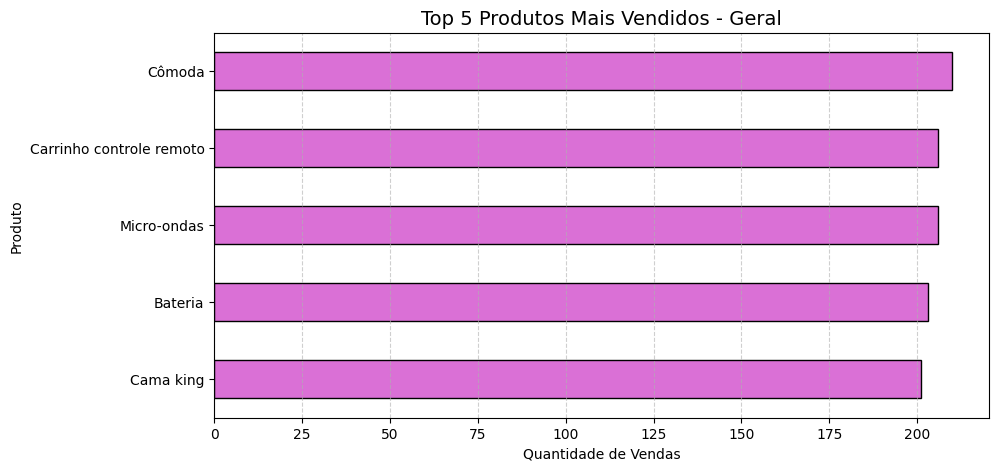

In [8]:
# 1. Identificando os 5 produtos mais vendidos no total (todas as lojas)
top_produtos = df_total['Produto'].value_counts().head(5)

# 2. Identificando os 5 produtos menos vendidos no total
piores_produtos = df_total['Produto'].value_counts().tail(5)

print("Top 5 Produtos Mais Vendidos:")
print(top_produtos)
print("\n5 Produtos Menos Vendidos:")
print(piores_produtos)

# 3. Criando a visualização (Gráfico de Barras Horizontais para o Top 5)
plt.figure(figsize=(10, 5))
top_produtos.sort_values().plot(kind='barh', color='orchid', edgecolor='black')

plt.title('Top 5 Produtos Mais Vendidos - Geral', fontsize=14)
plt.xlabel('Quantidade de Vendas')
plt.ylabel('Produto')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 5. Frete Médio por Loja

Frete Médio por Loja
Loja
Loja 1    34.691805
Loja 2    33.621941
Loja 3    33.074464
Loja 4    31.278997
Name: Frete, dtype: float64


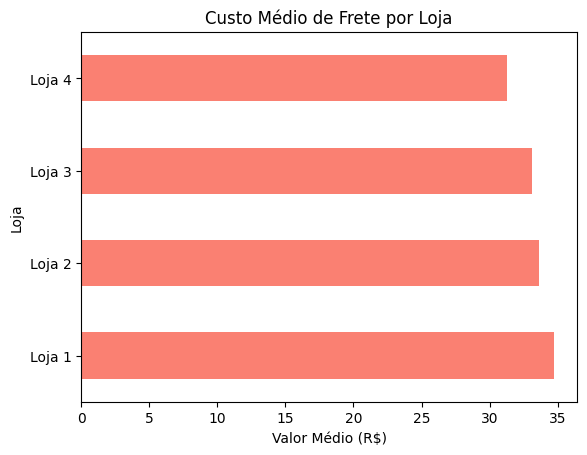

In [9]:
frete_medio = df_total.groupby('Loja')['Frete'].mean()
print('Frete Médio por Loja')
print(frete_medio)

# Gráfico 3: Histograma ou Barras para Frete
frete_medio.plot(kind='barh', color='salmon')
plt.title('Custo Médio de Frete por Loja')
plt.xlabel('Valor Médio (R$)')
plt.show()

# Relatório de Análise e Recomendação - Alura Store

## 1. Objetivo
Esta análise foi realizada para identificar qual das quatro unidades da rede Alura Store apresenta o menor desempenho global, auxiliando o Senhor João na decisão de venda para captação de novo capital de investimento.

## 2. Análise de Desempenho por Métrica

### 2.1. Faturamento Total
O faturamento é o principal indicador de saúde financeira. Observamos a seguinte hierarquia:
* **Loja 1:** R\$ 1.534.509,12 (Líder)
* **Loja 2:** R\$ 1.488.459,06
* **Loja 3:** R\$ 1.464.025,03
* **Loja 4:** R\$ 1.384.497,58 (Menor desempenho)

### 2.2. Avaliação dos Clientes
A satisfação média é equilibrada em toda a rede (entre 3.97 e 4.04).
* A **Loja 3** detém a melhor reputação (4.04).
* A **Loja 1**, apesar de vender mais, possui a menor média de satisfação (3.97).

### 2.3. Eficiência Logística (Frete Médio)
* A **Loja 4** possui o frete mais competitivo da rede (R\$ 31,27).
* A **Loja 1** possui o custo logístico mais elevado (R\$ 34,69).

## 3. Mix de Produtos e Categorias
Identificamos que a categoria de **Móveis** (com itens como Cômodas e Camas) e **Eletrodomésticos** (Micro-ondas) são os grandes motores de venda. Por outro lado, a categoria de **Livros** e itens de **Eletrônicos** específicos apresentam a menor saída, sugerindo uma necessidade de revisão de estoque nessas áreas.

## 4. Conclusão e Recomendação Final

Com base nos dados analisados, recomendo ao Senhor João a venda da **Loja 4**.

**Justificativa:**
Embora a Loja 4 apresente o custo de frete mais baixo da rede, ela não conseguiu converter essa vantagem competitiva em volume de vendas, apresentando o **menor faturamento total** entre as quatro unidades. Para o objetivo de levantar capital para um novo negócio, o desinvestimento na unidade com menor retorno financeiro bruto é a estratégia mais conservadora e segura.